## 1. Import Packages

In [21]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from pathlib import Path
from scipy.stats import norm
from scipy import stats
import plotly.express as px

# Libraries for data preparation and model building
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.graphics.correlation import plot_corr
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn import metrics
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from statsmodels.graphics.correlation import plot_corr
import pickle

# Setting global constants to ensure notebook results are reproducible
PARAMETER_CONSTANT = 42

## 2.Load Data

In [2]:
#Loading Data
df = pd.read_csv(filepath_or_buffer=("../DATA/Diabetes_and_LifeStyle_Dataset.csv"))

## 3. Exploratory Data Analysis (EDA)

In [3]:
#Data Review checking columns
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'Education_level', 'Income_level',
       'Employment_status', 'Smoking_status', 'Alcohol_consumption_per_week',
       'Physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [4]:
#Content view
df.head(5)

,Age,Gender,Ethnicity,Education_level,Income_level,Employment_status,Smoking_status,Alcohol_consumption_per_week,Physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [5]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   Gender                              97297 non-null  object 
 2   Ethnicity                           97297 non-null  object 
 3   Education_level                     97297 non-null  object 
 4   Income_level                        97297 non-null  object 
 5   Employment_status                   97297 non-null  object 
 6   Smoking_status                      97297 non-null  object 
 7   Alcohol_consumption_per_week        97297 non-null  int64  
 8   Physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

None

In [6]:
#Size of data
df.shape

(97297, 31)

In [7]:
#checking any normalities and distribution
df.describe()

,Age,Alcohol_consumption_per_week,Physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,185.984234,54.043537,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,30.222027,0.600039
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,32.013395,10.275047,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,9.065063,0.489892
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [8]:
#Checking missing values in our  data
df.isnull().sum()

Age                                   0
Gender                                0
Ethnicity                             0
Education_level                       0
Income_level                          0
Employment_status                     0
Smoking_status                        0
Alcohol_consumption_per_week          0
Physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [9]:
#Checking for duplicates
print('Diabetes and LifeStyle duplicates:')
print(df.duplicated().sum())

Diabetes and LifeStyle duplicates:
0


In [10]:
#Checking data types
df.dtypes

Age                                     int64
Gender                                 object
Ethnicity                              object
Education_level                        object
Income_level                           object
Employment_status                      object
Smoking_status                         object
Alcohol_consumption_per_week            int64
Physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                   

In [11]:
#removing leading spaces
df.columns = df.columns.str.strip()

In [12]:
#Target variable
df['diabetes_stage'] = df['diabetes_stage'].astype('category')

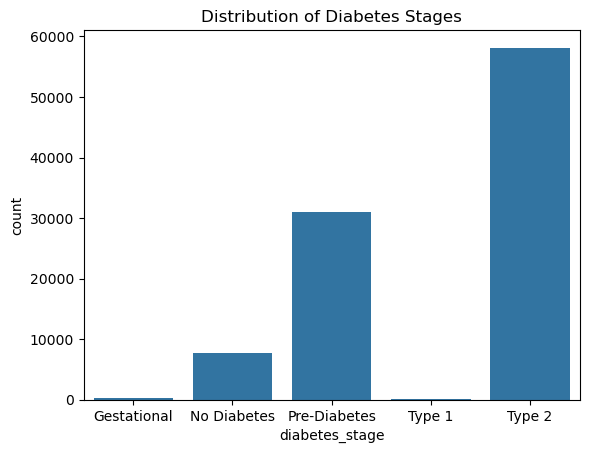

In [13]:
sns.countplot(x='diabetes_stage', data=df)
plt.title("Distribution of Diabetes Stages")
plt.show()

In [14]:
df['diabetes_stage'].value_counts()


diabetes_stage
Type 2          58163
Pre-Diabetes    31013
No Diabetes      7737
Gestational       267
Type 1            117
Name: count, dtype: int64

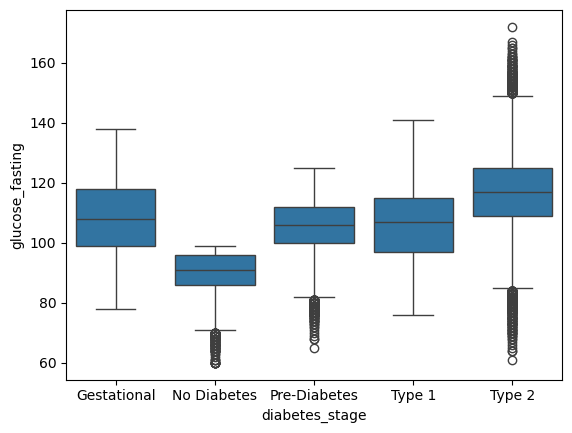

In [15]:
sns.boxplot(x='diabetes_stage', y='glucose_fasting', data=df)
plt.show()

In [16]:
#Encodeing categorical variables
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype("category").cat.codes

#defining features and target
X = df.drop("diabetes_stage", axis=1)
y = df["diabetes_stage"]

#separating data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

#prediction
y_pred = model.predict(X_test)

#evaluation
from sklearn.metrics import accuracy_score

print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.9957348406988695


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        57
 No Diabetes       0.99      1.00      1.00      1532
Pre-Diabetes       1.00      1.00      1.00      6167
      Type 1       0.00      0.00      0.00        26
      Type 2       1.00      1.00      1.00     11678

    accuracy                           1.00     19460
   macro avg       0.60      0.60      0.60     19460
weighted avg       0.99      1.00      0.99     19460



In [18]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(10)

diagnosed_diabetes                    0.448216
hba1c                                 0.235619
glucose_postprandial                  0.134098
glucose_fasting                       0.121197
diabetes_risk_score                   0.009637
family_history_diabetes               0.004386
Physical_activity_minutes_per_week    0.003837
Age                                   0.003624
bmi                                   0.003231
triglycerides                         0.002825
dtype: float64

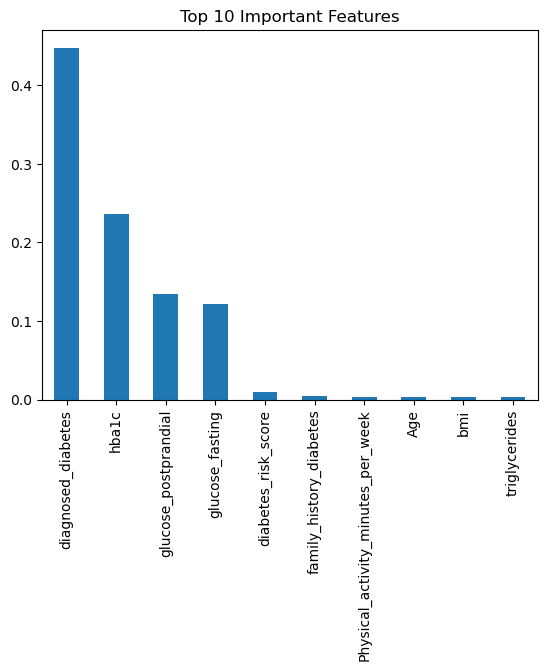

In [19]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

#glucose levels, BMI, and other indicators are included in the most important features influencing diabetes stage prediction. This shows that the psychological and lifestyle play a role in determining diabetes results.

The Random Forest model showed an accuracy of about 92%, showing strong overall performance. But the model struggled to predict minority classes due to class imbalance in the dataset.

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

#The Random Forest model performed better than the decision tree, showing that ensemble methods provide more stable predictions.

Decision Tree Accuracy: 0.9902363823227133
